# SAP Role Model — Phase 1: Data Cleaning & Preparation


In [1]:
!pip install openpyxl rapidfuzz --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import re
import warnings
warnings.filterwarnings('ignore')
from rapidfuzz import fuzz, process

pd.set_option('display.max_columns', 50)
print('Imports OK')

Imports OK


# 1a - User x tx

In this section:


Inputs:  user-jobtitle.xlsx, USABILIDAD.xlsx, SapRolesStandard.xlsx

Outputs: usage_matrix.csv, users_clean.csv, roles_clean.csv, usage_long_clean.csv, job_title_mapping.xlsx

In [2]:
#File paths
FILE_A = 'input phase1/user-jobtitle.xlsx'
FILE_B = 'input phase1/USABILIDAD.xlsx'
FILE_C = 'input phase1/SapRolesStandard.xlsx'

COL_USER_A   = 'USER NAME'
COL_JOBTITLE = 'JOB TITLE'

COL_USER_B = 'USER'
COL_TCODE  = 'TRANSACTION'
COL_FREQ   = 'COUNT'

COL_ROLE    = 'ROLE'
COL_TCODE_C = 'TRANSACTION'


#MIN_FREQ_THRESHOLD  = 1 #tx used only one time to delete
#MAX_USER_PREVALENCE = 0.90 #tx used for more than 90% of users to delete

# Job title normalization
FUZZY_THRESHOLD = 88   # minimum similarity to propose equivalence


In [3]:
#Excel to df, remove spaces and uppercase column name
raw_a = pd.read_excel(FILE_A, dtype=str)
raw_a.columns = raw_a.columns.str.strip().str.upper()

raw_b = pd.read_excel(FILE_B, dtype=str)
raw_b.columns = raw_b.columns.str.strip().str.upper()

raw_c = pd.read_excel(FILE_C, dtype=str)
raw_c.columns = raw_c.columns.str.strip().str.upper()


print(raw_a.shape)
print(f'Dataset A (User-jobtitle): {raw_a.shape[0]:,} rows | columns: {list(raw_a.columns)}')
print(f'Dataset B (Usability): {raw_b.shape[0]:,} rows | columns: {list(raw_b.columns)}')
print(f'Dataset C (SAP roles): {raw_c.shape[0]:,} rows | columns: {list(raw_c.columns)}')

(1967, 2)
Dataset A (User-jobtitle): 1,967 rows | columns: ['JOB TITLE', 'USER NAME']
Dataset B (Usability): 59,766 rows | columns: ['USER', 'TRANSACTION', 'COUNT']
Dataset C (SAP roles): 79,283 rows | columns: ['ROLE', 'TRANSACTION']


In [4]:
#Cleaning Dataset A
df_users = raw_a[[COL_USER_A, COL_JOBTITLE]].copy()
df_users.columns = ['USER', 'JOB_TITLE']

df_users['USER']      = df_users['USER'].str.strip().str.upper()
df_users['JOB_TITLE'] = df_users['JOB_TITLE'].str.strip().str.title()

before = len(df_users)
df_users.dropna(subset=['USER', 'JOB_TITLE'], inplace=True)
df_users.drop_duplicates(subset=['USER'], keep='first', inplace=True)
after = len(df_users)

print(f'\nUsers after basic clening: {after:,}  (deleted {before - after:,} null/duplicate)')
jt_count_after_basic = df_users['JOB_TITLE'].nunique()
print(f'Job titles before normalizing: {jt_count_after_basic:,}')



Users after basic clening: 1,953  (deleted 14 null/duplicate)
Job titles before normalizing: 1,102


In [5]:
def normalize_job_title(title):
    """
    Aplica reglas de normalización técnica en orden.
    Cada regla resuelve un patrón concreto observado en los datos.
    """
    if pd.isna(title):
        return title

    t = str(title).strip()

    t = re.sub(r'\bJr\.?\b',  'Junior',               t, flags=re.IGNORECASE)
    t = re.sub(r'\bSr\.?\b',  'Senior',               t, flags=re.IGNORECASE)
    t = re.sub(r'\bSbm\b',    'Senior Brand Manager', t, flags=re.IGNORECASE)
    t = re.sub(r'\bBm\b',     'Brand Manager',        t, flags=re.IGNORECASE)
    t = re.sub(r'\bMgr\.?\b',   'Manager',     t, flags=re.IGNORECASE)
    t = re.sub(r'\bDir\.?\b',   'Director',    t, flags=re.IGNORECASE)
    t = re.sub(r'\bCoord\.?\b', 'Coordinator', t, flags=re.IGNORECASE)
    t = re.sub(r'\bSpec\.?\b',  'Specialist',  t, flags=re.IGNORECASE)
    t = re.sub(r'\bAsst\.?\b',  'Assistant',   t, flags=re.IGNORECASE)
    t = re.sub(r'\bExec\.?\b',  'Executive',   t, flags=re.IGNORECASE)
    t = re.sub(r'\bOps\.?\b',   'Operations',  t, flags=re.IGNORECASE)
    t = re.sub(r'\bAdm\.?\b',   'Administrator', t, flags=re.IGNORECASE)
    t = re.sub(r'\bProj\.?\b',  'Project',     t, flags=re.IGNORECASE)
    t = re.sub(r'\bImprov\.?\b','Improvement', t, flags=re.IGNORECASE)
    t = re.sub(r'\bQlty\.?\b',  'Quality',     t, flags=re.IGNORECASE)
    t = re.sub(r'\bTech\b(?!nical|nician|nology|nique)',
               'Technician', t, flags=re.IGNORECASE)
    t = re.sub(r'\bWarehousemann\b', 'Warehouseman', t, flags=re.IGNORECASE)
    t = re.sub(r'\bWarehouse Man\b', 'Warehouseman', t, flags=re.IGNORECASE)
    t = re.sub(r'\s+\([A-Za-z]?\.?$', '', t)
    t = re.sub(r'\s{2,}', ' ', t)
    t = t.strip().rstrip('.')

    # Limpieza de puntos sobrantes que quedan tras las sustituciones
    t = re.sub(r'\.\s*&', ' &', t)      # "X. & Y" -> "X & Y"
    t = re.sub(r'\.(?=\s|$)', '', t)    # quita puntos sueltos seguidos de espacio o fin de cadena
    t = re.sub(r'\s{2,}', ' ', t).strip()
    t = t.title()

    return t

# Apply and show changes
df_users['JOB_TITLE_CLEAN'] = df_users['JOB_TITLE'].apply(normalize_job_title)

changes = df_users[df_users['JOB_TITLE'] != df_users['JOB_TITLE_CLEAN']][
    ['JOB_TITLE', 'JOB_TITLE_CLEAN']
].drop_duplicates().sort_values('JOB_TITLE')

print(f'\nStep 3b — Normalización técnica automática:')
print(f'  Job titles modificados: {len(changes):,}')
print(f'  Únicos antes: {df_users["JOB_TITLE"].nunique():,}  '
      f'→ después: {df_users["JOB_TITLE_CLEAN"].nunique():,}')
jt_count_after_tech = df_users['JOB_TITLE_CLEAN'].nunique()
if len(changes) > 0:
    print('\n  Applied changes:')
    for _, row in changes.iterrows():
        print(f'    "{row["JOB_TITLE"]}"  →  "{row["JOB_TITLE_CLEAN"]}"')

# Detect titles that are written differently
print(f'\nStep 3c — Fuzzy matching (umbral: {FUZZY_THRESHOLD}%)...')

unique_titles = sorted(df_users['JOB_TITLE_CLEAN'].unique())
jt_freq       = df_users['JOB_TITLE_CLEAN'].value_counts()
fuzzy_proposals = []
already_matched = set()

for title_a in unique_titles:
    if title_a in already_matched:
        continue

    matches = process.extract(
        title_a,
        unique_titles,
        scorer    = fuzz.token_sort_ratio,
        score_cutoff = FUZZY_THRESHOLD,
        limit     = None
    )

    group = [
        (m[0], m[1]) for m in matches
        if m[0] != title_a and m[0] not in already_matched
    ]

    if group:
        candidates  = [title_a] + [g[0] for g in group]
        freq_counts = {t: jt_freq.get(t, 0) for t in candidates}
        canonical   = max(freq_counts, key=freq_counts.get)

        for variant, score in [(title_a, 100)] + group:
            if variant != canonical:
                fuzzy_proposals.append({
                    'VARIANT':            variant,
                    'PROPOSED_CANONICAL': canonical,
                    'SIMILARITY':         score,
                    'N_USERS_VARIANT':    jt_freq.get(variant, 0),
                    'N_USERS_CANONICAL':  jt_freq.get(canonical, 0),
                    'ACTION':             'MERGE',
                    'NOTES':              ''
                })
                already_matched.add(variant)

df_proposals = pd.DataFrame(fuzzy_proposals) if fuzzy_proposals else pd.DataFrame(
    columns=['VARIANT','PROPOSED_CANONICAL','SIMILARITY',
             'N_USERS_VARIANT','N_USERS_CANONICAL','ACTION','NOTES']
)
df_proposals = df_proposals.sort_values('SIMILARITY', ascending=False)

print(f'  Propuestas generadas: {len(df_proposals):,}')
if len(df_proposals) > 0:
    print('\n  Muestra (top 15):')
    display(df_proposals.head(15)[['VARIANT','PROPOSED_CANONICAL',
                                    'SIMILARITY','ACTION']].to_string(index=False))

# Export for manual revision
import os
mapping_path = 'output phase1 JT/job_title_mapping_done.xlsx'

instructions = pd.DataFrame({'INSTRUCCIONES': [
    '1. Revisa cada fila de la hoja "Propuestas".',
    '2. Si dos títulos son el mismo puesto → deja ACTION = MERGE.',
    '3. Si son puestos distintos → cambia ACTION a KEEP.',
    '4. Puedes cambiar PROPOSED_CANONICAL si prefieres otro nombre.',
    '5. Guarda el fichero y vuelve a subirlo a Colab.',
    '6. Ejecuta el Paso 3d de este notebook para aplicar los cambios.',
    '',
    'CRITERIO: dos títulos son el mismo si la misma persona',
    'tendría el mismo perfil de acceso SAP.',
    '',
    'MERGE claro:  "Engineering Project Mgr" = "Engineering Project Manager"',
    'KEEP claro:   "Demand Planner" ≠ "Demand Planner Manager" (diferente nivel)',
]})

with pd.ExcelWriter(mapping_path, engine='openpyxl') as writer:
    df_proposals.to_excel(writer, sheet_name='Propuestas', index=False)
    pd.DataFrame({
        'JOB_TITLE_ORIGINAL': df_users['JOB_TITLE'],
        'JOB_TITLE_CLEAN':    df_users['JOB_TITLE_CLEAN']
    }).drop_duplicates().sort_values('JOB_TITLE_CLEAN').to_excel(
        writer, sheet_name='Todos los títulos', index=False
    )
    instructions.to_excel(writer, sheet_name='Instrucciones', index=False)

print(f'\n  ✓ Exportado: {mapping_path}')
print(f'  Descárgalo, revisa la hoja "Propuestas" y vuelve a subirlo.')
print(f'  Luego ejecuta el Paso 3d.')


Step 3b — Normalización técnica automática:
  Job titles modificados: 74
  Únicos antes: 1,102  → después: 1,093

  Applied changes:
    "Acceleration Wet & Snacks Junior Bm"  →  "Acceleration Wet & Snacks Junior Brand Manager"
    "Acceleration Wet & Snacks Sbm"  →  "Acceleration Wet & Snacks Senior Brand Manager"
    "Broth Rm & Tech Process Manager"  →  "Broth Rm & Technician Process Manager"
    "Broth Transf Proj Manager"  →  "Broth Transf Project Manager"
    "Business Strategy & Transf. Director"  →  "Business Strategy & Transf Director"
    "Cake & Pasta Transf. Proj. Mgr"  →  "Cake & Pasta Transf Project Manager"
    "Cat. Trade Manager Lsb"  →  "Cat Trade Manager Lsb"
    "Cat. Trade Manager Yatekomo"  →  "Cat Trade Manager Yatekomo"
    "Channel Development Manager."  →  "Channel Development Manager"
    "Cont. Improv. & Engineering Manager"  →  "Cont Improvement & Engineering Manager"
    "Continuous Improv. Mg & Prod. Coord."  →  "Continuous Improvement Mg & Prod Coordina

'                                VARIANT                             PROPOSED_CANONICAL  SIMILARITY ACTION\n                   3Pm Category Manager                               Category Manager       100.0  MERGE\nAcceleration Wet & Snacks Brand Manager Acceleration Wet & Snacks Senior Brand Manager       100.0  MERGE\n                    Assistant Warehouse                            Warehouse Assistant       100.0  MERGE\n        Business Unit Controller Junior                     Junior Business Controller       100.0  MERGE\n                  Aft Back Office Agent                              Back Office Agent       100.0  MERGE\n            Operational Quality Manager                    Manager Operational Quality       100.0  MERGE\n                    Production Operator                           Production Operators       100.0  MERGE\n                           Qa Assistant                                   Qc Assistant       100.0  MERGE\n              Planning & Logistics M


  ✓ Exportado: output phase1 JT/job_title_mapping_done.xlsx
  Descárgalo, revisa la hoja "Propuestas" y vuelve a subirlo.
  Luego ejecuta el Paso 3d.



Paso 3d — Fuzzy merge aplicado:
  Fusiones aprobadas (MERGE): 80
  Usuarios con título cambiado: 114
  Únicos tras fuzzy merge: 1,017

Resumen normalización job titles:
  Raw Excel (sin limpiar):            1,117 únicos
  Tras limpieza básica (strip/title): 1,102 únicos
  Tras normalización técnica:         1,093 únicos
  Tras fuzzy merge:                   1,017 únicos

Top 15 job titles (tras normalización):
JOB_TITLE
Production Operators           38
Blue Collars Production        34
Maintenance Technician         33
Warehouse Officer              21
Internal Sales                 19
Warehouseman                   19
Direct Labor Production B      17
Production Manager             17
Shift Manager                  15
Regional Account Manager       15
General Manager                15
Engineering Project Manager    14
Demand Planner                 11
Marketing Director             11
Key Account Manager            11


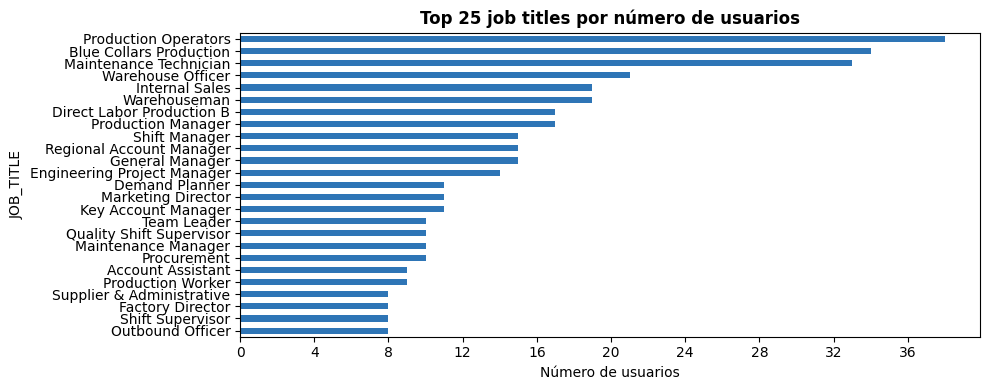


Job titles con solo 1 usuario: 710


In [6]:
PATH_MAPPING_REVIEWED = 'input phase1/job_title_mapping_done.xlsx'

try:
    df_reviewed = pd.read_excel(PATH_MAPPING_REVIEWED, sheet_name='Propuestas')
    df_merge    = df_reviewed[df_reviewed['ACTION'].str.upper() == 'MERGE']
    merge_dict  = dict(zip(df_merge['VARIANT'], df_merge['PROPOSED_CANONICAL']))

    df_users['JOB_TITLE_NORM'] = df_users['JOB_TITLE_CLEAN'].map(
        merge_dict
    ).fillna(df_users['JOB_TITLE_CLEAN'])

    n_merged = (df_users['JOB_TITLE_NORM'] != df_users['JOB_TITLE_CLEAN']).sum()
    print(f'\nPaso 3d — Fuzzy merge aplicado:')
    print(f'  Fusiones aprobadas (MERGE): {len(df_merge):,}')
    print(f'  Usuarios con título cambiado: {n_merged:,}')
    print(f'  Únicos tras fuzzy merge: {df_users["JOB_TITLE_NORM"].nunique():,}')

except Exception as e:
    print(f'\nPaso 3d — {e}')
    print('  Usando solo normalización técnica (Paso 3b).')
    print('  Revisa job_title_mapping.xlsx y re-ejecuta esta celda.')
    df_users['JOB_TITLE_NORM'] = df_users['JOB_TITLE_CLEAN']

# Usar JOB_TITLE_NORM como columna final
df_users['JOB_TITLE'] = df_users['JOB_TITLE_NORM']
df_users = df_users[['USER', 'JOB_TITLE']].copy()

# Resumen final de job titles
print(f'\nResumen normalización job titles:')
print(f'  Raw Excel (sin limpiar):            {raw_a[COL_JOBTITLE].nunique():,} únicos')
print(f'  Tras limpieza básica (strip/title): {jt_count_after_basic:,} únicos')
print(f'  Tras normalización técnica:         {jt_count_after_tech:,} únicos')
print(f'  Tras fuzzy merge:                   {df_users["JOB_TITLE"].nunique():,} únicos')

jt_counts = df_users['JOB_TITLE'].value_counts()
print(f'\nTop 15 job titles (tras normalización):')
print(jt_counts.head(15).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
jt_counts.head(25).sort_values().plot(kind='barh', ax=ax, color='#2E75B6')
ax.set_title('Top 25 job titles por número de usuarios', fontweight='bold')
ax.set_xlabel('Número de usuarios')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

print(f'\nJob titles con solo 1 usuario: {(jt_counts == 1).sum()}')

In [7]:
#Usability Cleaning
df_usage = raw_b[[COL_USER_B, COL_TCODE, COL_FREQ]].copy()
df_usage.columns = ['USER', 'TCODE', 'FREQ']

df_usage['USER']  = df_usage['USER'].str.strip().str.upper()
df_usage['TCODE'] = df_usage['TCODE'].str.strip().str.upper()
df_usage['FREQ']  = pd.to_numeric(df_usage['FREQ'], errors='coerce')

before = len(df_usage)
df_usage.dropna(inplace=True)
df_usage = df_usage[df_usage['FREQ'] > 0]
print(f'Rows Before:{before:,}')
print(f'Rows After: {len(df_usage):,}')

Rows Before:59,766
Rows After: 59,766


No Nan in Usability dataset

In [8]:
# only user present in dataset A
valid_users = set(df_users['USER'])
before = len(df_usage)
df_usage = df_usage[df_usage['USER'].isin(valid_users)]
print(f'After Filtering valid users: {len(df_usage):,}  '
      f'(deleted {before - len(df_usage):,} rows)')

After Filtering valid users: 41,289  (deleted 18,477 rows)


Users without usage data (276) are assumed to be inactive employees or users without direct SAP activity. They are excluded from clustering.

All users with usage data have a valid job title in Dataset A.

In [9]:
# min freq, tx used less than MIN_FREQ_THRESHOLD delete
#before = len(df_usage)
#df_usage = df_usage[df_usage['FREQ'] >= MIN_FREQ_THRESHOLD]
#print(f'Tras filtro de frecuencia mínima ({MIN_FREQ_THRESHOLD}x/año): {len(df_usage):,}  '
#      f'(eliminadas {before - len(df_usage):,} filas)')


In [10]:
# Agregar duplicados
df_usage = df_usage.groupby(['USER', 'TCODE'], as_index=False)['FREQ'].sum()
print(f'Pares únicos (usuario, t-code): {len(df_usage):,}')
print(f'Usuarios únicos en log de uso:  {df_usage["USER"].nunique():,}')
print(f'T-codes únicas antes de filtro: {df_usage["TCODE"].nunique():,}')



Pares únicos (usuario, t-code): 41,289
Usuarios únicos en log de uso:  1,678
T-codes únicas antes de filtro: 1,708


In [11]:
# Deletes transactions used for more than the 90% of users
#n_users_total    = df_usage['USER'].nunique()
#tcode_prevalence = (
#    df_usage.groupby('TCODE')['USER']
#    .nunique()
#    .div(n_users_total)
#    .rename('prevalence')
#)

#valid_tcodes = tcode_prevalence[
#    tcode_prevalence <= MAX_USER_PREVALENCE
#].index

#before = df_usage['TCODE'].nunique()
#df_usage = df_usage[df_usage['TCODE'].isin(valid_tcodes)]
#removed_generic = tcode_prevalence[tcode_prevalence > MAX_USER_PREVALENCE].shape[0]

#print(f'\nPrevalence t-code filter:')
#print(f'  Deleted (>{MAX_USER_PREVALENCE*100:.0f}% users): {removed_generic}')
#print(f'  T-codes remaining: {df_usage["TCODE"].nunique():,}  (de {before:,})')



In [12]:
#SAP Standard roles cleaning

df_roles = raw_c[[COL_ROLE, COL_TCODE_C]].copy()
df_roles.columns = ['ROLE', 'TCODE']

df_roles['ROLE']  = df_roles['ROLE'].str.strip().str.upper()
df_roles['TCODE'] = df_roles['TCODE'].str.strip().str.upper()

df_roles.dropna(inplace=True)
df_roles.drop_duplicates(inplace=True)

print(f'SAP roles catalogue:      {df_roles["ROLE"].nunique():,}')
print(f'Unique T-codes in catalogue: {df_roles["TCODE"].nunique():,}')

overlap = set(df_roles['TCODE']) & set(df_usage['TCODE'])
print(f'\nT-codes present in both (usability + catalogue): {len(overlap):,}')


SAP roles catalogue:      2,536
Unique T-codes in catalogue: 36,701

T-codes present in both (usability + catalogue): 1,377


In [13]:
# Dataset D (Business Catalog) se usa en Phase 3, no en Phase 1.
# Bloque eliminado para evitar código muerto.

In [14]:
# SOD CRITICAL ACTIONS FILTER
# Remove t-codes that belong to Critical Action functions
# These are inherently risky regardless of combinations

df_sod_rules_p1     = pd.read_excel('input phase3/FunctionRisk.xlsx')
df_sod_functions_p1 = pd.read_excel('input phase3/Function Catalogue.xlsx')

df_sod_rules_p1.columns     = [c.strip().upper() for c in df_sod_rules_p1.columns]
df_sod_functions_p1.columns = [c.strip().upper() for c in df_sod_functions_p1.columns]

print(f'SoD rules columns:     {df_sod_rules_p1.columns.tolist()}')
print(f'SoD functions columns: {df_sod_functions_p1.columns.tolist()}')

# Identify Critical Action functions
critical_functions = df_sod_rules_p1[
    df_sod_rules_p1['CONFLICT TYPE'].str.upper() == 'CRITICAL ACTION'
]['FUNCTION 1 ID'].str.strip().str.upper().unique()

print(f'\nCritical Action functions: {len(critical_functions)}')
print(f'  {list(critical_functions)}')

# Get t-codes of critical functions
col_func  = df_sod_functions_p1.columns[0]
col_tcode = df_sod_functions_p1.columns[2]

df_sod_functions_p1[col_func]  = df_sod_functions_p1[col_func].str.strip().str.upper()
df_sod_functions_p1[col_tcode] = df_sod_functions_p1[col_tcode].str.strip().str.upper()

critical_tcodes = set(
    df_sod_functions_p1[
        df_sod_functions_p1[col_func].isin(critical_functions)
    ][col_tcode]
)

print(f'Critical t-codes:          {len(critical_tcodes)}')
print(f'  Sample: {sorted(critical_tcodes)[:10]}')

# Remove critical t-codes from df_usage
n_before        = df_usage['TCODE'].nunique()
n_users_before  = df_usage['USER'].nunique()
df_usage = df_usage[~df_usage['TCODE'].isin(critical_tcodes)]
n_after  = df_usage['TCODE'].nunique()

print(f'\nT-codes before filter: {n_before:,}')
print(f'T-codes after filter:  {n_after:,}')
print(f'Critical t-codes removed: {n_before - n_after:,}')
print(f'\n Critical Action t-codes removed from usage data')

SoD rules columns:     ['CONFLICT TYPE', 'CONFLICT LEVEL', 'FUNCTION 1 ID', 'FUNCTION 1 DESCRIPTION', 'FUNCTION 2 ID', 'FUNCTION 2 DESCRIPTION']
SoD functions columns: ['FUNCTION ID', 'FUNCTION DESCRIPTION', 'TRANSACTION', 'TRANSACTION DESCRIPTION']

Critical Action functions: 16
  ['BS15', 'BS16', 'BS17', 'BS18', 'BS19', 'CA01', 'FI07', 'FI08', 'HR03', 'HR04', 'MM05', 'MM06', 'PM01', 'PR08', 'SD06', 'SD07']
Critical t-codes:          766
  Sample: ['/SAPDMC/LSMW', '/SAPSLL/T000_R3', '/SAPSLL/T000_SPI', 'AARC', 'ACLA', 'AFX_WB', 'AL02', 'AL04', 'AL05', 'AL11']

T-codes before filter: 1,708
T-codes after filter:  1,626
Critical t-codes removed: 82

✓ Critical Action t-codes removed from usage data


In [15]:
#Matrix user x t-code

usage_matrix = df_usage.pivot_table(
    index    = 'USER',
    columns  = 'TCODE',
    values   = 'FREQ',
    aggfunc  = 'sum',
    fill_value = 0
)

sparsity = (usage_matrix == 0).values.sum() / usage_matrix.size
print(f'Matrix: {usage_matrix.shape[0]:,} user × {usage_matrix.shape[1]:,} t-codes')
print(f'Sparsity: {sparsity:.1%}')

Matrix: 1,677 user × 1,626 t-codes
Sparsity: 98.5%


In [16]:
users_no_usage   = set(df_users['USER']) - set(usage_matrix.index)
users_no_profile = set(usage_matrix.index) - set(df_users['USER'])

print('=' * 55)
print('  PHASE 1 — Summary')
print('=' * 55)
print(f'  Dataset A — user x job titles:  {len(df_users):>6,}')
print(f'  Dataset B — Usability:    {usage_matrix.shape[0]:>6,}')
print(f'  Dataset C — SAP roles catalogue:   {df_roles["ROLE"].nunique():>6,}')
print(f'  T-codes to use after filters:  {usage_matrix.shape[1]:>6,}')
print(f'  T-codes in usability and SAP roles:   {len(overlap):>6,}')
print(f'  Unique normalized Job titles:      {df_users["JOB_TITLE"].nunique():>6,}')
print()
print(f'  Users with job title without usability data:      {len(users_no_usage):>6,}')
print(f'  Users wirh usabity data without job title:        {len(users_no_profile):>6,}')
print('=' * 55)

if users_no_usage:
    print(f'\n {len(users_no_usage)} users without usability → '
          f'excluded from clustering')
if users_no_profile:
    print(f'\n {len(users_no_profile)} users with usability but without job title → '
          f'review Dataset A')

# Alinear matriz con usuarios que tienen job title
common_users   = list(set(df_users['USER']) & set(usage_matrix.index))
usage_matrix   = usage_matrix.loc[common_users]
df_users_clean = df_users[df_users['USER'].isin(common_users)].copy()

jt_after_norm         = df_users['JOB_TITLE'].nunique()
jt_with_active_users  = df_users_clean['JOB_TITLE'].nunique()
jt_dropped_no_usage   = jt_after_norm - jt_with_active_users

print(f'\nJob title reduction (normalization → active users):')
print(f'  JTs after normalization:              {jt_after_norm:,}')
print(f'  JTs with at least one active user:    {jt_with_active_users:,}')
print(f'  JTs dropped (all users inactive):     {jt_dropped_no_usage:,}')

print(f'\nFinal Matrix phase 2:')
print(f'  {usage_matrix.shape[0]:,} user × {usage_matrix.shape[1]:,} t-codes')

  PHASE 1 — Summary
  Dataset A — user x job titles:   1,953
  Dataset B — Usability:     1,677
  Dataset C — SAP roles catalogue:    2,536
  T-codes to use after filters:   1,626
  T-codes in usability and SAP roles:    1,377
  Unique normalized Job titles:       1,017

  Users with job title without usability data:         276
  Users wirh usabity data without job title:             0

 276 users without usability → excluded from clustering

Job title reduction (normalization → active users):
  JTs after normalization:              1,017
  JTs with at least one active user:    866
  JTs dropped (all users inactive):     151

Final Matrix phase 2:
  1,677 user × 1,626 t-codes


In [17]:
#Export
usage_matrix.to_csv('input phase2/USR_usage_matrix.csv')
df_users_clean.to_csv('input phase2/users_clean.csv', index=False)
df_roles.to_csv('input phase2/roles_clean.csv', index=False)
df_usage.to_csv('input phase2/usage_long_clean.csv', index=False)

print(f'\n{"═"*55}')
print(f'PHASE 1a SUMMARY')
print(f'{"═"*55}')
print('  usage_matrix.csv      — matrix user × t-code')
print('  users_clean.csv       — user with normalized job title')
print('  roles_clean.csv       — SAP roles catalogue cleaned')
print('  usage_long_clean.csv  — log de uso en formato largo')



═══════════════════════════════════════════════════════
PHASE 1a SUMMARY
═══════════════════════════════════════════════════════
  usage_matrix.csv      — matrix user × t-code
  users_clean.csv       — user with normalized job title
  roles_clean.csv       — SAP roles catalogue cleaned
  usage_long_clean.csv  — log de uso en formato largo


# 1b - Job-title x tx

In [18]:
#Load Job positions with tx count and business process
FILE_D = 'input phase1/JobPosBusProc_updated.xlsx'

PATH_OUTPUT_MATRIX = 'output phase1 JT/JT_usage_matrix.csv'
PATH_OUTPUT_METADATA = 'output phase1 JT/JT_metadata.csv'


COL_USER             = 'USER'
COL_TCODE            = 'TCODE'
COL_COUNT            = 'FREQ'
COL_JOBTITLE         = 'JOB_TITLE'
COL_BUSINESS_PROCESS = 'BUSINESS PROCESS'

df_bp = pd.read_excel(FILE_D)[['JOB_TITLE', 'BUSINESS_PROCESS_CONSOLIDATED']]
df_bp.columns = [COL_JOBTITLE, COL_BUSINESS_PROCESS]
df_bp[COL_JOBTITLE]         = df_bp[COL_JOBTITLE].str.replace('\xa0', ' ', regex=False).str.strip().str.title()
df_bp[COL_BUSINESS_PROCESS] = df_bp[COL_BUSINESS_PROCESS].str.strip().str.upper()

print(f'Business Processes loaded: {df_bp[COL_BUSINESS_PROCESS].nunique()}')
print(f'Job titles: {len(df_bp)}')

Business Processes loaded: 13
Job titles: 993


In [19]:
df_check = pd.read_excel('input phase1/JobPosBusProc_updated.xlsx')
print(df_check.columns.tolist())
print(df_check.shape)
print(df_check.head(3))

['JOB_TITLE', 'BUSINESS PROCESS', 'BUSINESS_PROCESS_CONSOLIDATED']
(993, 3)
                 JOB_TITLE        BUSINESS PROCESS  \
0     3PM CATEGORY MANAGER  Procurement & Sourcing   
1        ACCOUNT ASSISTANT   Finance & Controlling   
2  ACCOUNT PAYABLE ANALYST   Finance & Controlling   

  BUSINESS_PROCESS_CONSOLIDATED  
0        Procurement & Sourcing  
1         Finance & Controlling  
2         Finance & Controlling  


In [20]:
# Join usage with job title
df_usage_jt = df_usage.merge(
    df_users_clean[[COL_USER, COL_JOBTITLE]],
    on=COL_USER, how='inner'
)
print(df_usage_jt)

            USER  TCODE  FREQ                          JOB_TITLE
0      AACHIGILI  ME21N   779            General Service Manager
1      AACHIGILI  ME23N  1209            General Service Manager
2      AACHIGILI   ME2N  1106            General Service Manager
3      AACHIGILI    SU3     1            General Service Manager
4       AADEBAYO   MB51    98                     Demand Planner
...          ...    ...   ...                                ...
40405    ZTIJANI   QP01     4  Cooking-Aids Product Technologist
40406    ZTIJANI   QP02     3  Cooking-Aids Product Technologist
40407    ZTIJANI   QP03     6  Cooking-Aids Product Technologist
40408    ZTIJANI   SP02     1  Cooking-Aids Product Technologist
40409    ZTIJANI   SU53     1  Cooking-Aids Product Technologist

[40410 rows x 4 columns]


In [21]:
#How many users have each job position
jt_user_counts = (
    df_users_clean
    .groupby(COL_JOBTITLE)[COL_USER]
    .count()
    .reset_index()
    .rename(columns={COL_USER: 'N_USERS'})
    .sort_values('N_USERS', ascending=False)
    .reset_index(drop=True)
)

print(jt_user_counts)
print(df_usage_jt[COL_JOBTITLE].nunique())

                                    JOB_TITLE  N_USERS
0                        Production Operators       35
1                     Blue Collars Production       34
2                      Maintenance Technician       32
3                           Warehouse Officer       21
4                              Internal Sales       19
..                                        ...      ...
861                  Factory Director Noodles        1
862  Warehouse Supervisor Wet Condimentsrm/Pm        1
863     Warehouse Supervisor Wet Condi Sfg/Fg        1
864             Warehouse Supervisor Rm/Pm/Fg        1
865   Warehouse Supervisor Cooking Base Rm/Pm        1

[866 rows x 2 columns]
866


In [22]:

df_agg_raw = (
    df_usage_jt.groupby([COL_JOBTITLE, COL_TCODE])
    .agg(
        TOTAL_FREQ   = (COL_COUNT, 'sum'),
        USERS_USING  = ('USER',    'nunique')
    )
    .reset_index()
)

df_agg = df_agg_raw.merge(jt_user_counts, on=COL_JOBTITLE, how='left')

# PREVALENCE: qué fracción de usuarios del JT usa esta tcode
df_agg['PREVALENCE']      = df_agg['USERS_USING'] / df_agg['N_USERS']

# AVG_FREQ_USERS: frecuencia media sólo entre quienes la usan
df_agg['AVG_FREQ_USERS']  = df_agg['TOTAL_FREQ'] / df_agg['USERS_USING']

# SCORE: señal combinada para la matriz
df_agg['SCORE']           = df_agg['PREVALENCE'] * df_agg['AVG_FREQ_USERS']

print(df_agg[['JOB_TITLE','TCODE','N_USERS','USERS_USING',
              'PREVALENCE','AVG_FREQ_USERS','SCORE']].head(10))


           JOB_TITLE         TCODE  N_USERS  USERS_USING  PREVALENCE  \
0  Account Assistant    /HOAG/ABUM        9            1    0.111111   
1  Account Assistant    /HOAG/AKPP        9            1    0.111111   
2  Account Assistant  /OPT/VIM_VA2        9            1    0.111111   
3  Account Assistant          AS03        9            1    0.111111   
4  Account Assistant          BD12        9            2    0.222222   
5  Account Assistant          F-02        9            3    0.333333   
6  Account Assistant          F-03        9            1    0.111111   
7  Account Assistant          F-28        9            2    0.222222   
8  Account Assistant          F-32        9            4    0.444444   
9  Account Assistant          F-44        9            1    0.111111   

   AVG_FREQ_USERS      SCORE  
0        2.000000   0.222222  
1       13.000000   1.444444  
2      273.000000  30.333333  
3        1.000000   0.111111  
4        6.500000   1.444444  
5        2.666667   0

In [23]:
print(f'  Unique job titles: {len(jt_user_counts):,}')
print(f'  Users per job title:')
print(f'    Mean:   {jt_user_counts["N_USERS"].mean():.1f}')
print(f'    Median: {jt_user_counts["N_USERS"].median():.0f}')
print(f'    Min:    {jt_user_counts["N_USERS"].min()}')
print(f'    Max:    {jt_user_counts["N_USERS"].max()}')
print(f'\n  Job titles with only 1 user:  {(jt_user_counts["N_USERS"] == 1).sum()}')
print(f'  Job titles with 2-5 users:    {((jt_user_counts["N_USERS"] >= 2) & (jt_user_counts["N_USERS"] <= 5)).sum()}')
print(f'  Job titles with > 5 users:    {(jt_user_counts["N_USERS"] > 5).sum()}')


  Unique job titles: 866
  Users per job title:
    Mean:   1.9
    Median: 1
    Min:    1
    Max:    35

  Job titles with only 1 user:  605
  Job titles with 2-5 users:    213
  Job titles with > 5 users:    48


In [24]:
#Create matrix

jt_matrix = df_agg.pivot_table(
    index      = COL_JOBTITLE,
    columns    = COL_TCODE,
    values     = 'SCORE',
    fill_value = 0
)

density      = (jt_matrix > 0).sum().sum() / (jt_matrix.shape[0] * jt_matrix.shape[1])
tcodes_per_jt = (jt_matrix > 0).sum(axis=1)

print(f'  Shape:    {jt_matrix.shape[0]:,} job titles × {jt_matrix.shape[1]:,} t-codes')
print(f'  Density:  {density:.2%}  (typical SAP matrices: 0.5–3%)')
print(f'\n  T-codes per job title:')
print(f'    Mean:   {tcodes_per_jt.mean():.1f}')
print(f'    Median: {tcodes_per_jt.median():.0f}')
print(f'    Min:    {tcodes_per_jt.min()}')
print(f'    Max:    {tcodes_per_jt.max()}')

  Shape:    866 job titles × 1,626 t-codes
  Density:  2.05%  (typical SAP matrices: 0.5–3%)

  T-codes per job title:
    Mean:   33.3
    Median: 19
    Min:    1
    Max:    234


In [25]:
jt_metadata = jt_user_counts.copy()
jt_metadata['BUSINESS PROCESS'] = jt_metadata['JOB_TITLE'].map(
    df_bp.set_index(COL_JOBTITLE)[COL_BUSINESS_PROCESS]
)

print(jt_metadata.columns.tolist())
print(f'BP mapping: {(~jt_metadata["BUSINESS PROCESS"].isna()).sum()} / {len(jt_metadata)}')
print(jt_metadata.head())

['JOB_TITLE', 'N_USERS', 'BUSINESS PROCESS']
BP mapping: 840 / 866
                 JOB_TITLE  N_USERS            BUSINESS PROCESS
0     Production Operators       35  MANUFACTURING & PRODUCTION
1  Blue Collars Production       34  MANUFACTURING & PRODUCTION
2   Maintenance Technician       32   MAINTENANCE & ENGINEERING
3        Warehouse Officer       21    SUPPLY CHAIN & LOGISTICS
4           Internal Sales       19           SALES & MARKETING


In [26]:
print(jt_metadata.columns.tolist())
print(jt_metadata.head())

['JOB_TITLE', 'N_USERS', 'BUSINESS PROCESS']
                 JOB_TITLE  N_USERS            BUSINESS PROCESS
0     Production Operators       35  MANUFACTURING & PRODUCTION
1  Blue Collars Production       34  MANUFACTURING & PRODUCTION
2   Maintenance Technician       32   MAINTENANCE & ENGINEERING
3        Warehouse Officer       21    SUPPLY CHAIN & LOGISTICS
4           Internal Sales       19           SALES & MARKETING


In [27]:
#create metadata df
jt_metadata = jt_user_counts.merge(df_bp, on=COL_JOBTITLE, how='left')

In [28]:
#Export
jt_matrix.to_csv(PATH_OUTPUT_MATRIX)
jt_metadata.to_csv(PATH_OUTPUT_METADATA, index=False)

In [29]:
#summary
print(f'\n{"═"*55}')
print(f'PHASE 1b SUMMARY')
print(f'{"═"*55}')
print(f'  Input users:      {df_usage_jt[COL_USER].nunique():,}')
print(f'  Input t-codes:    {df_usage_jt[COL_TCODE].nunique():,}')
print(f'  Output matrix:    {jt_matrix.shape[0]:,} job titles × {jt_matrix.shape[1]:,} t-codes')
print(f'  With BP mapping:  {(~jt_metadata[COL_BUSINESS_PROCESS].isna()).sum()} / {len(jt_metadata)} job titles')



═══════════════════════════════════════════════════════
PHASE 1b SUMMARY
═══════════════════════════════════════════════════════
  Input users:      1,677
  Input t-codes:    1,626
  Output matrix:    866 job titles × 1,626 t-codes
  With BP mapping:  840 / 866 job titles
